# Myllia - echoes of silenced genes
---

**authors**: [fsb2210](https://www.kaggle.com/fsb2210), [julianc93](https://www.kaggle.com/julianc93)

The task is to train a model that is able to predict *expression changes in scRNA-seq data induced by CRISPRi perturbations*. For that, we have a dataset of 80 different perturbations and the *average expression values* of genes, plus an unperturbed case (*non-targeting sgRNA*).

## Introduction

This notebook outlines the model architecture along with the validation scheme, and the calibration techniques used.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import kstest
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, MultiTaskLasso, HuberRegressor, RidgeCV
from sklearn.model_selection import RepeatedKFold, KFold, StratifiedKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor

We also include the score used by the challenge:

In [2]:
import sys
sys.path.append("../src")

from metric import _score_impl, _weighted_cosine

def compute_metric_by_components(y_true, y_pred, w, baseline_wmae, eps=1e-12, max_log2=5.0, cos_left=0.0, cos_right=0.2):
    # - compute sum_wmae component
    abs_err = np.abs(y_true - y_pred)
    pred_wmae = np.mean(abs_err * w, axis=1)
    pred_wmae = np.maximum(pred_wmae, eps)
    baseline = np.maximum(baseline_wmae, eps)
    terms = np.log2(baseline / pred_wmae)
    terms = np.minimum(terms, max_log2)
    sum_wmae = float(np.sum(terms))

    # - compute wcos component using the existing function
    wcos = _weighted_cosine(y_pred.ravel(), y_true.ravel(), left=cos_left, right=cos_right, eps=eps)

    # - final score
    final_score = float(sum_wmae * max(0.0, wcos))

    return round(final_score, 5), round(sum_wmae, 4), round(wcos, 4)

Define global options:

In [3]:
experiment_name = "pbde_pca300_signatures_kf_ridgecv_1em2_to_1e2"

# directory with data files
data_dir = "../data"
working_dir = "../data"

# random state integer value for reproducibility concerns
random_state = 42

# variance percentile to keep genes that vary significantly across perturbations, used for training a ML model
reduce_input_dim = False
n_latent_in = 1024

# whether to apply a StandardScaler to X features
apply_scaler_to_input = False

# reduce dimensions of output space genes to this number in the latent space
reduce_output_dim = False
n_latent = 75

# value for K-fold cross-validation technique
n_splits = 5

# flag to save images and predictions as files
save_files = False

# filename of figure
fig_fname = f"../reports/figures/{experiment_name}.png"

# OOF predictions and submission filenames (DataFrame structures saved)
oof_preds_fname = f"../data/oof_preds/{experiment_name}.csv"
submission_fname = f"../submissions/submissions_{experiment_name}.csv"

## Data loading

We start by loading the already created features (`X` and `X_val`) of embeddings along with external gene signatures. Also, we load the delta expressions that our model will learn to predict (`Y`).

In [4]:
# train & validation sets
X = np.load(f"{data_dir}/processed/X_esm2_pca_train.npy")
X_val = np.load(f"{data_dir}/processed/X_esm2_pca_val.npy")
Y = np.load(f"{data_dir}/processed/Y_esm2_pca_train.npy")

Also, we load the ground truth values matching the training set: `delta_true`, `weights_true` and `baseline_true`. These values will be used during model training, in order to find the best solution (maximizing the metric):

In [5]:
# train & validation sets
train_df = pd.read_csv(f"{data_dir}/training_data_means.csv")
val_df = pd.read_csv(f"{data_dir}/pert_ids_val.csv")

# list of genes
train_pert_genes = train_df["pert_symbol"].tolist()[:-1]
val_pert_genes = val_df["pert"].tolist()
output_genes = train_df.columns[1:]

# ground truth
ground_truth = pd.read_csv(f"{data_dir}/training_data_ground_truth_table.csv")
weight_cols = [f"w_{g}" for g in output_genes]

# true values (used later on, when computing metric)
delta_true = ground_truth[output_genes].values
weights_true = ground_truth[weight_cols].values
baseline_true = ground_truth["baseline_wmae"].values

### Extra feature preprocessing

This is present just in case we want to make some modifications to the already processed input features and output delta expressions:

In [6]:
n_internal = 80
n_external = X.shape[0] - n_internal

# reduce input dimensions using PCA
if reduce_input_dim:
    pca_in = PCA(n_components=n_latent_in, random_state=random_state)
    X_pca = pca_in.fit_transform(X)
    X_pca_val = pca_in.transform(X_val)
    X = X_pca.copy()
    X_val = X_pca_val.copy()

# scale input features
if apply_scaler_to_input:
    scaler = StandardScaler()
    scaler.fit(X[:n_internal])
    X = scaler.transform(X)
    X_val = scaler.transform(X_val)

# apply PCA to output vector to reduce dims into a latent space
if reduce_output_dim:
    delta_internal = Y[:n_internal]
    pca_resp = PCA(n_components=n_latent, random_state=random_state)
    pca_resp.fit(delta_internal)
    Y = pca_resp.transform(Y)

In [7]:
X.shape, X_val.shape, Y.shape

((80, 1581), (60, 1581), (80, 5127))

## Model definition and training

We are now ready to train a machine learning model using the features derived for each of the perturbations in the training dataset as inputs and the computed delta expressions for 5127 genes as outputs.

### Model architecture

* **Algorithm:** Ridge Regression with built-in cross-validation (`sklearn.linear_model.RidgeCV`).
* **Regularization values:** Alphas searched: $[10^{-2}, 10^{-1}, 10^{0}, 10^{1}, 10^{2}]$.
* **Objective:** Minimizes Mean Squared Error (MSE) with $L_2$ penalty.
  $$
  \min_{w} ||Xw - Y||_2^2 + \alpha ||w||_2^2
  $$

### Cross-validation scheme

* **Strategy:** 5-Fold KFold cross-validation.
  * **Splits:** `n_splits = 5`.
  * **Shuffle:** True (`random_state = 42`).
* **Out-of-Fold (OOF) predictions:** Accumulated across folds to evaluate generalization on the 80 training samples.

### Magnitude calibration

We have seen that the predictions of the Ridge model shinks such that they tend to have a lower variance than true values ($\sigma_{pred} < \sigma_{true}$). This tends to have a negative impact on the mean absolute error (MAE) component of the metric. Thus we apply a post-hoc standard deviation scaling.

* **Scaling factor ($\gamma$):** Computed per fold during CV (for OOF).
  $$
  \gamma = \frac{\text{std}(Y_{true})}{\text{std}(Y_{pred})}
  $$

Then, each prediction is scaled before being evaluated:
$$
    Y_{\rm final} = \gamma \times Y_{\rm pred}
$$

In [8]:
start_time = time.time()

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

oof_preds = np.zeros_like(Y)
oof_counts = np.zeros(len(Y))
val_preds = np.zeros((len(X_val), len(output_genes)))
scores, wmae, wcos = [], [], []
scaling_factors = []
pbar = tqdm(enumerate(cv.split(X)), desc="model training", total=n_splits, initial=0)
for k, (tr, va) in pbar:
    X_tr, X_va = X[tr], X[va]
    Y_tr, Y_va = Y[tr], Y[va]

    # === RidgeCV model
    model = RidgeCV(alphas=(1e-2, 1e-1, 1, 10, 100), cv=5)
    model.fit(X_tr, Y_tr)

    # predictions
    if reduce_output_dim:
        Y_pred = pca_resp.inverse_transform(multi_model.predict(X_va))
        Y_val = pca_resp.inverse_transform(multi_model.predict(X_val))
    else:
        Y_pred = model.predict(X_va)
        Y_val = model.predict(X_val)

    std_pred = np.std(Y_pred)
    std_true = np.std(Y_va)
    factor = std_true / std_pred if std_pred > 0 else 1
    scaling_factors.append(factor)

    # save OOF predictions
    oof_preds[va] += Y_pred * factor
    oof_counts[va] += 1
    # make predictions on validation set, final answer is average over the entire models
    val_preds += Y_val / n_splits

    internal_mask = va < n_internal
    if np.any(internal_mask):
        # filter the predictions and true values to ONLY the internal samples
        Y_pred_internal = Y_pred[internal_mask] * factor
        Y_va_internal = Y_va[internal_mask]

        # get weights and baselines
        internal_indices = va[internal_mask]
        W_va = weights_true[internal_indices]
        B_va = baseline_true[internal_indices]

        # compute metric
        fold_score, fold_wmae, fold_wcos = compute_metric_by_components(Y_va_internal, Y_pred_internal, W_va, B_va)
        scores.append(fold_score)
        wmae.append(fold_wmae)
        wcos.append(fold_wcos)

        pbar.set_postfix({"score": f"{fold_score:.4f}", "wmae": f"{fold_wmae:.4f}", "wcos": f"{fold_wcos:.4f}"})

training_time = time.time() - start_time
print(f"training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

model training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:17<00:00,  3.40s/it, score=0.6449, wmae=1.6121, wcos=0.4001]

training completed in 17.02 seconds (0.28 minutes)


In [9]:
# average OOF predictions (each sample seen multiple times)
if any(oof_counts > 1): oof_preds = oof_preds / oof_counts[:, np.newaxis]

oof_predictions = oof_preds
overall_score, overall_wmae, overall_wcos = compute_metric_by_components(Y, oof_predictions, weights_true, baseline_true)

median_scale = np.median(scaling_factors)
val_preds *= median_scale

In [10]:
print(f"- Per-fold averages:")
print(f"  - score:    {np.mean(scores):.4f} +/- {np.std(scores):.4f} :: {scores}")
print(f"  - sum_wmae: {np.mean(wmae):.4f} +/- {np.std(wmae):.4f} :: {wmae}")
print(f"  - wcos:     {np.mean(wcos):.4f} +/- {np.std(wcos):.4f} :: {wcos}")

print(f"- Overall OOF (all 80 samples):")
print(f"  - score:    {overall_score:.4f}")
print(f"  - sum_wmae: {overall_wmae:.4f}")
print(f"  - wcos:     {overall_wcos:.4f}")

pred_std_per_sample = oof_predictions.std(axis=1)
true_std_per_sample = Y.std(axis=1)
print(f"- Diagnostics:")
print(f"  - median of scaling factors: {median_scale:.3f}")
print(f"  - pred_std/true_std ratio: {pred_std_per_sample.mean() / true_std_per_sample.mean():.3f}")

abs_err = np.abs(Y - oof_predictions)
pred_wmae_per_pert = np.mean(abs_err * weights_true, axis=1)
n_beating = (pred_wmae_per_pert < baseline_true).sum()
print(f"  - perturbations beating baseline: {n_beating}/80")

- Per-fold averages:
  - score:    1.0187 +/- 0.5909 :: [0.50058, 2.10759, 0.66253, 1.17785, 0.64492]
  - sum_wmae: 2.3738 +/- 0.7527 :: [1.7022, 3.7098, 2.3448, 2.4999, 1.6121]
  - wcos:     0.4032 +/- 0.1080 :: [0.2941, 0.5681, 0.2826, 0.4712, 0.4001]
- Overall OOF (all 80 samples):
  - score:    5.3033
  - sum_wmae: 11.8687
  - wcos:     0.4468
- Diagnostics:
  - median of scaling factors: 2.667
  - pred_std/true_std ratio: 1.044
  - perturbations beating baseline: 66/80


## Results

Let's start by showing how each component of the metric behaves as a function of the CV fold

### Metrics across folds

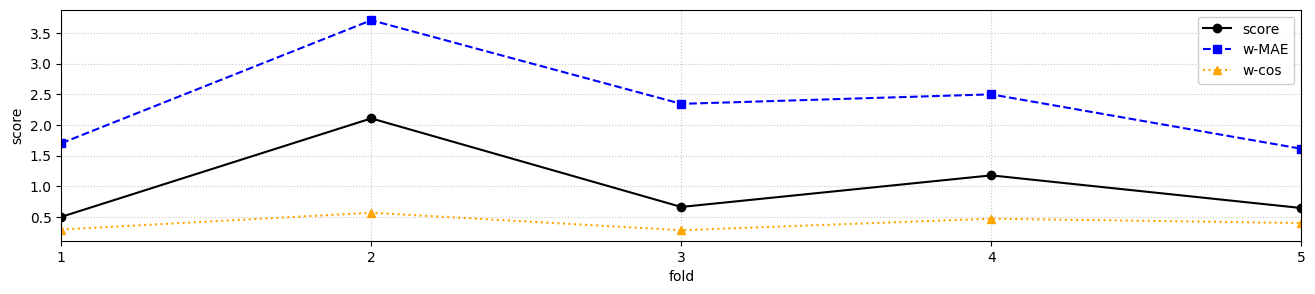

In [11]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.set_xlabel("fold")
ax.set_ylabel("score")
ax.set_xlim(1, len(scores))
ax.set_xticks(range(1, len(scores)+1))
ax.grid(True, linestyle=":", alpha=0.7)
xx = range(1, len(scores)+1)
ax.plot(xx, scores, marker="o", label="score", color="black", linewidth=1.5)
ax.plot(xx, wmae, marker="s", label="w-MAE", color="blue", linewidth=1.5, linestyle="--")
ax.plot(xx, wcos, marker="^", label="w-cos", color="orange", linewidth=1.5, linestyle=":")
ax.legend(loc="best", frameon=True, framealpha=0.95);

### Delta expressions of target genes

Next is a nice visual exploration of how different our OOF predictions behave in comparison to the true values

In [12]:
# calculate correlation per gene (axis=0)
corrs = []
for i in range(Y.shape[1]):
    # handle cases where variance is 0 to avoid NaNs
    if np.std(Y[:, i]) > 1e-6:
        corr = np.corrcoef(Y[:, i], oof_predictions[:, i])[0, 1]
        corrs.append(corr)
corrs = np.array(corrs)

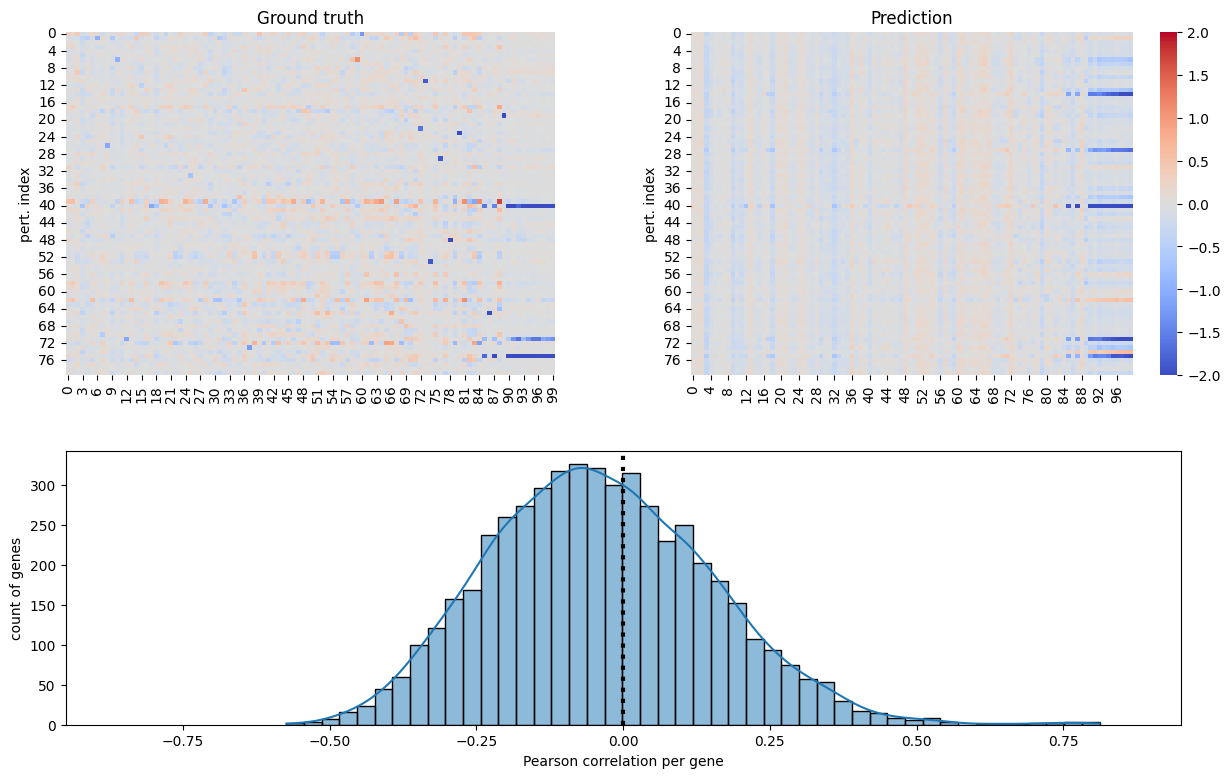

In [13]:
# select top 50 most variable genes based on ground truth variance
gene_vars = np.var(Y, axis=0)
top_idx = np.argsort(gene_vars)[-100:]
y_true_subset = Y[:, top_idx]
pred_subset = oof_predictions[:, top_idx]

fig_shape = (16, 9)
fig = plt.figure(figsize=fig_shape)

# Top row: two heatmaps with shared colorbar
ax1 = plt.subplot2grid((20, 20), (0, 0), colspan=8, rowspan=10)
im1 = sns.heatmap(y_true_subset, cmap="coolwarm", center=0, ax=ax1, cbar=False, vmin=-2, vmax=2)
ax1.set_title("Ground truth")
ax1.set_ylabel("pert. index")

ax2 = plt.subplot2grid((20, 20), (0, 10), colspan=9, rowspan=10)
im2 = sns.heatmap(pred_subset, cmap="coolwarm", center=0, ax=ax2, cbar=True, vmin=-2, vmax=2)
ax2.set_title("Prediction")
ax2.set_ylabel("pert. index")

# Bottom row: correlation histogram spanning full width
ax3 = plt.subplot2grid((20, 20), (12, 0), colspan=18, rowspan=9)
sns.histplot(corrs, kde=True, ax=ax3)
ax3.axvline(x=0, color="black", linestyle=":", lw=3)
ax3.set_xlim(-0.95, 0.95)
ax3.set_xlabel("Pearson correlation per gene")
ax3.set_ylabel("count of genes")

if save_files: plt.savefig(fig_fname);

Or we can be more precise and compare true and predicted values using the following three figures

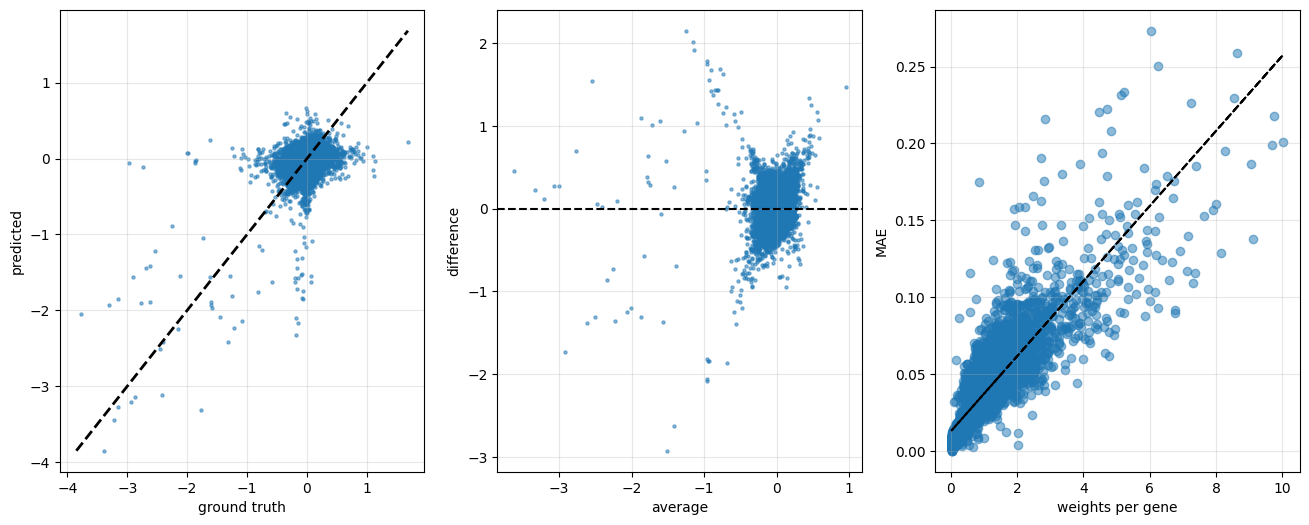

In [14]:
fig, ax = plt.subplots(figsize=(16, 6), ncols=3)

# 1. scatter plot
y_flat = Y.flatten()
pred_flat = oof_predictions.flatten()

ax[0].set_xlabel("ground truth")
ax[0].set_ylabel("predicted")
ax[0].scatter(y_flat, pred_flat, alpha=0.5, s=5) # Alpha makes it readable for dense data
min_val = min(y_flat.min(), pred_flat.min())
max_val = max(y_flat.max(), pred_flat.max())
ax[0].plot([min_val, max_val], [min_val, max_val], color="black", ls="--", lw=2)
ax[0].grid(True, alpha=0.3)

# 2. Bland-Altman plot
mean_vals = (Y + oof_predictions) / 2
diff_vals = Y - oof_predictions

ax[1].scatter(mean_vals.flatten(), diff_vals.flatten(), alpha=0.5, s=5)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_xlabel("average")
ax[1].set_ylabel("difference")
ax[1].grid(True, alpha=0.3)

# 3. w vs MAE
mae_per_gene = np.mean(np.abs(Y - oof_predictions), axis=0)
w_per_gene = weights_true.mean(axis=0)
z = np.polyfit(w_per_gene, mae_per_gene, 1)
p = np.poly1d(z)

ax[2].scatter(w_per_gene, mae_per_gene, alpha=0.5)
ax[2].set_xlabel("weights per gene")
ax[2].set_ylabel("MAE")
ax[2].grid(True, alpha=0.3)
ax[2].plot(w_per_gene, p(w_per_gene), color="black", ls="--");

> NOTE: dashed lines in the left and center most figures represent the case in which predictions are exactly equal to ground truth values

In [15]:
mask = w_per_gene > 5
print(f"number of cases with weights > 5: {mae_per_gene[mask].shape[0]}, mean MAE (weights > 5): {mae_per_gene[mask].mean():.3f}")

number of cases with weights > 5: 70, mean MAE (weights > 5): 0.147


In [16]:
print(f"min value oof_preds: {oof_predictions.min():.4f} (ground truth min value: {Y.min():.4f})")
print(f"max value oof_preds: {oof_predictions.max():.4f} (ground truth max value: {Y.max():.4f})")

min value oof_preds: -3.8511 (ground truth min value: -3.7784)
max value oof_preds: 0.6627 (ground truth max value: 1.6851)


In addition, we also save OOF predictions in case we want to use them for an ensemble stacking or hill climbing approach:

In [17]:
oof_preds_df = pd.DataFrame(oof_predictions, columns=output_genes)
oof_preds_df.insert(0, "pert_symbol", train_pert_genes)
if save_files: oof_preds_df.to_csv(oof_preds_fname, index=False)
oof_preds_df.head()

,pert_symbol,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,ACLY,0.034837,-0.000696,-0.013196,0.005842,-0.036577,0.000378,0.012211,0.000838,0.017395,...,0.078260,-0.000829,-0.000799,0.004446,0.019142,0.029463,-0.050162,-0.045357,-0.028322,-0.006810
1,ALDOA,0.029444,-0.003707,0.001307,0.019842,-0.040707,-0.001244,0.017609,0.010037,0.011325,...,0.050950,0.001360,-0.011719,0.005021,0.013203,0.032343,-0.033750,-0.048893,0.010788,-0.009903
2,APAF1,0.008881,0.001417,-0.006631,0.011353,-0.011774,0.000387,0.001444,0.001416,0.017364,...,0.046707,-0.000228,0.001973,0.003280,0.012279,0.022327,-0.024246,-0.047159,-0.013540,0.001087
3,ARID2,0.026730,-0.003737,-0.004859,-0.010951,-0.010853,-0.001540,-0.019406,-0.004074,0.033378,...,0.062650,-0.000399,0.009036,0.004847,0.019802,0.021926,-0.052680,-0.080010,-0.020717,-0.017497
4,BAG1,0.043687,-0.004045,-0.005865,-0.009734,-0.026330,0.001439,0.004413,0.001057,0.024879,...,0.063922,-0.001125,-0.006555,0.008239,0.027219,0.027259,-0.049714,-0.063575,-0.034818,-0.007863


In [18]:
train_df.head()

,pert_symbol,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,ACLY,0.311642,0.022102,0.100949,0.378671,0.715857,0.000000,0.118900,0.030792,0.087006,...,0.290693,0.002349,0.638608,0.031022,0.036856,0.097390,0.914845,0.647727,0.720461,0.603572
1,ALDOA,0.627445,0.043961,0.094335,0.442062,0.658125,0.000000,0.200191,0.000000,0.061549,...,0.390909,0.000000,0.371624,0.045867,0.087408,0.124600,0.821529,0.801302,0.545344,0.553567
2,APAF1,0.467114,0.030714,0.090910,0.470155,0.732770,0.002820,0.118370,0.025851,0.137382,...,0.359183,0.000000,0.535496,0.009991,0.053445,0.069219,0.855117,0.709241,0.674747,0.667791
3,ARID2,0.517185,0.018776,0.102561,0.445692,0.687079,0.010236,0.124519,0.016378,0.123456,...,0.353383,0.000000,0.557026,0.017552,0.062452,0.094811,0.731613,0.614643,0.629297,0.619404
4,BAG1,0.409021,0.034862,0.129969,0.462849,0.819877,0.002999,0.125579,0.002677,0.131047,...,0.286078,0.000000,0.611761,0.008581,0.052864,0.126885,0.899319,0.714828,0.646969,0.636020


## Inference

We are now ready to save predictions on the 60 genes found in the validation dataset along with 60 more dummy predictions for the not-yet available genes in the test dataset:

In [19]:
val_ids = val_df["pert_id"].tolist()

preds = pd.DataFrame(val_preds, columns=output_genes)
preds.insert(0, "pert_id", val_ids)
pad = pd.DataFrame(0, index=range(60), columns=output_genes)
pad.insert(0, "pert_id", [f"pert_{i}" for i in range(61, 121)])

submission = pd.concat([preds, pad], ignore_index=True)
if save_files: submission.to_csv(submission_fname, index=False)
submission.head()

,pert_id,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
0,pert_1,0.015992,0.004682,-0.012395,-0.008997,-0.023758,-0.000753,-0.019222,-0.003872,0.043711,...,0.074355,-0.001614,0.014653,0.006507,0.016972,0.034977,-0.044159,-0.045673,-0.027015,-0.018772
1,pert_2,0.017494,-0.000251,-0.004070,-0.002703,-0.019442,0.000121,-0.008716,-0.001038,0.033279,...,0.062377,-0.000912,0.005815,0.006815,0.021858,0.027286,-0.043484,-0.077954,-0.036926,-0.012990
2,pert_3,0.010325,0.000512,-0.011239,0.010434,-0.026145,-0.000569,-0.003176,-0.000666,0.026886,...,0.072296,-0.000523,0.006025,0.005750,0.016604,0.030720,-0.041440,-0.056342,-0.026738,-0.012183
3,pert_4,0.023950,-0.001676,-0.001031,-0.007350,-0.011622,0.000408,-0.011131,-0.001811,0.035706,...,0.058944,-0.000815,0.004445,0.008692,0.024669,0.025950,-0.050814,-0.086954,-0.039873,-0.018066
4,pert_5,0.021377,0.001689,-0.003365,-0.014967,-0.013140,-0.000455,-0.019404,-0.002695,0.041017,...,0.061410,-0.001061,0.008095,0.008989,0.024895,0.029384,-0.042564,-0.066842,-0.040119,-0.031362
